In [1]:
# Cell 1: Imports and Setup
import pandas as pd
import sqlite3
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

DB_PATH = '../data/telecom.db'
SQL_QUERY_PATH = '../sql/get_churn_data.sql'
MODEL_DIR = '../saved_models/'
BEST_MODEL_PATH = os.path.join(MODEL_DIR, 'best_churn_model.joblib')
SCALER_PATH = os.path.join(MODEL_DIR, 'scaler.joblib')

os.makedirs(MODEL_DIR, exist_ok=True)

In [2]:
# Cell 2: Load Data from Database 🗃️
conn = sqlite3.connect(DB_PATH)
with open(SQL_QUERY_PATH, 'r') as file:
    sql_query = file.read()
df = pd.read_sql_query(sql_query, conn)
conn.close()
print("Data loaded successfully from the database.")
df.head()

Data loaded successfully from the database.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,...,MultipleLines,InternetService_DSL,InternetService_FiberOptic,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Churn
0,0002-ORFBO,Female,0,Yes,Yes,9,One year,Yes,Mailed check,65.6,...,0,1,0,0,1,0,1,1,0,0
1,0003-MKNFE,Male,0,No,No,9,Month-to-month,No,Mailed check,59.9,...,1,1,0,0,0,0,0,0,1,0
2,0004-TLHLJ,Male,0,No,No,4,Month-to-month,Yes,Electronic check,73.9,...,0,0,1,0,0,1,0,0,0,1
3,0011-IGKFF,Male,1,Yes,No,13,Month-to-month,Yes,Electronic check,98.0,...,0,0,1,0,1,1,0,1,1,1
4,0013-EXCHZ,Female,1,Yes,No,3,Month-to-month,Yes,Mailed check,83.9,...,0,0,1,0,0,0,1,1,0,1


In [3]:
# Cell 3: Data Preprocessing and Feature Engineering
df_processed = df.drop('customerID', axis=1)
categorical_cols = ['gender', 'Partner', 'Dependents', 'Contract', 'PaperlessBilling', 'PaymentMethod']
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
df_processed['MonthlyChargeTenureRatio'] = df_processed['MonthlyCharges'] / (df_processed['tenure'] + 1)
print("Preprocessing complete.")

Preprocessing complete.


In [4]:
# Cell 4: Model Preparation
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [5]:
# Cell 5: Scale Numerical Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Data scaling complete.")

Data scaling complete.


In [7]:
# Cell 6: Train Multiple Models
# --- Model 1: Logistic Regression (Good for interpretability) ---
log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression model trained.")

# --- Model 2: Random Forest (Often more powerful) ---
rand_forest = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rand_forest.fit(X_train_scaled, y_train)
print("Random Forest model trained.")

Logistic Regression model trained.
Random Forest model trained.


In [8]:
# Cell 7: Evaluate and Compare Models
# --- Predictions ---
y_pred_lr = log_reg.predict(X_test_scaled)
y_pred_rf = rand_forest.predict(X_test_scaled)

# --- Evaluation ---
print("--- Logistic Regression Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

print("\n--- Random Forest Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

--- Logistic Regression Evaluation ---
Accuracy: 0.7527
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1033
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1407
   macro avg       0.72      0.77      0.72      1407
weighted avg       0.81      0.75      0.77      1407


--- Random Forest Evaluation ---
Accuracy: 0.7854
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.45      0.53       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.69      1407
weighted avg       0.77      0.79      0.77      1407



C:\Users\HP\AppData\Local\Temp\ipykernel_8076\3345302403.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=rf_importance_df.head(10), palette='viridis')


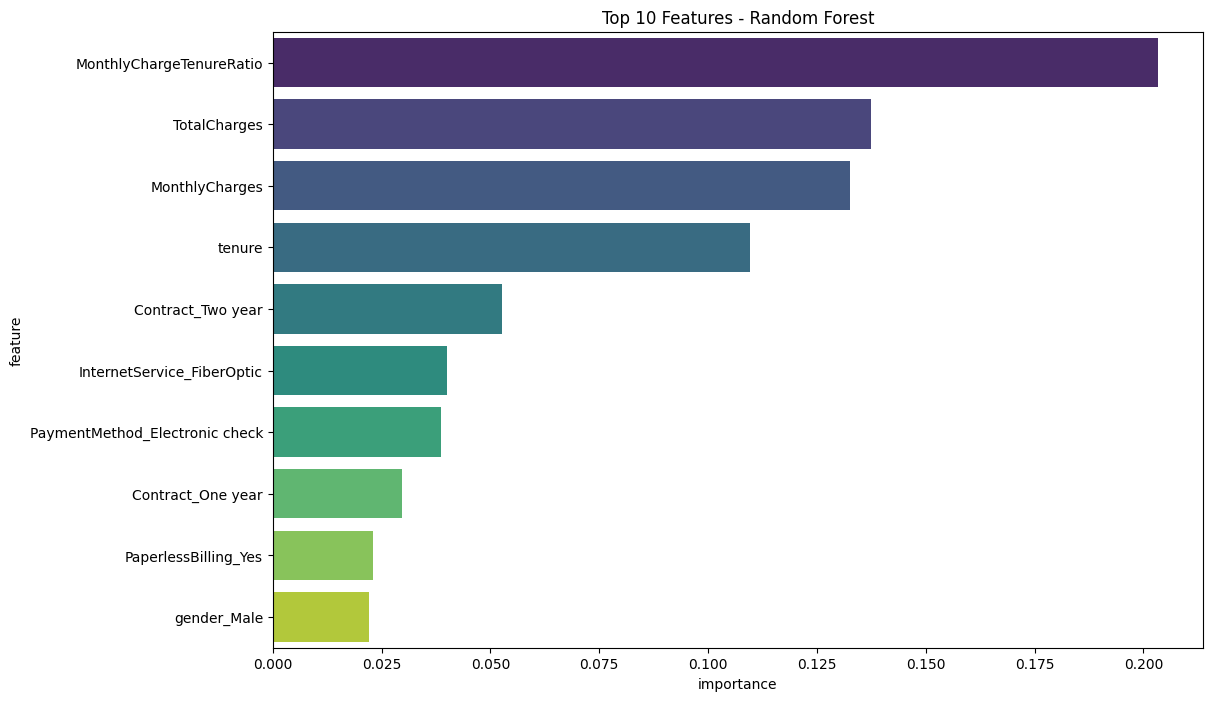

C:\Users\HP\AppData\Local\Temp\ipykernel_8076\3345302403.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y='feature', data=pd.concat([lr_coeffs_df.head(5), lr_coeffs_df.tail(5)]), palette='coolwarm')


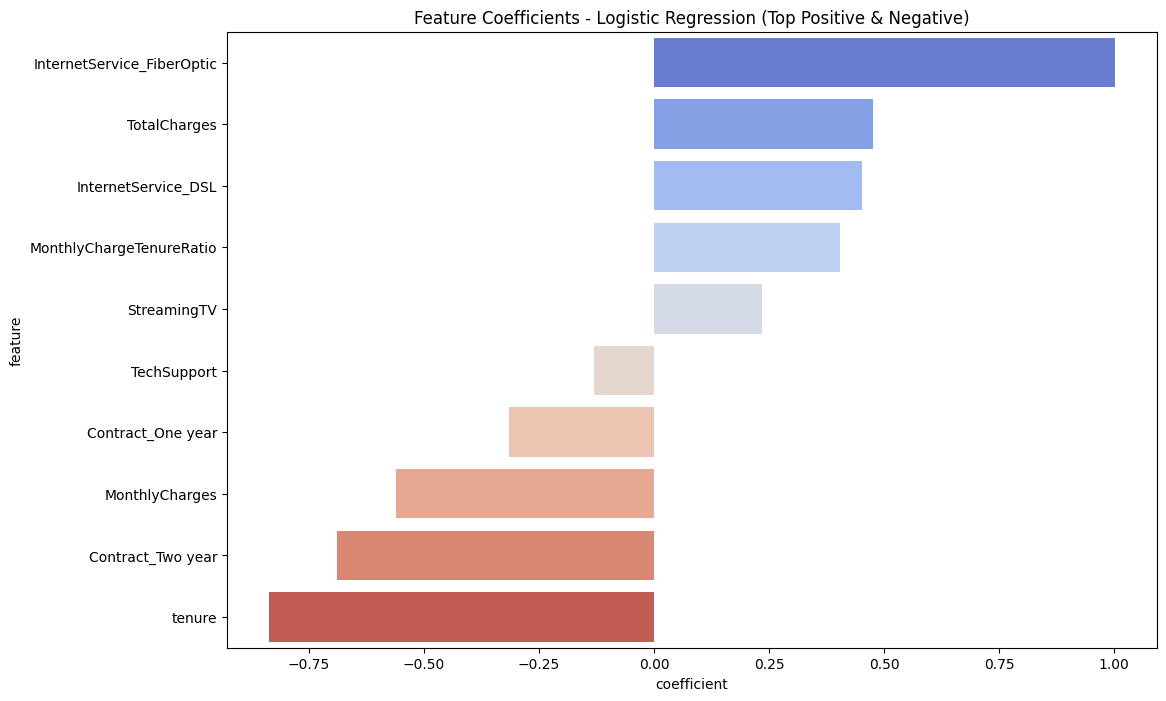

In [10]:
# Cell 8: Analyze Model Insights
# --- Random Forest Feature Importance ---
importances = rand_forest.feature_importances_
feature_names = X.columns
rf_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=rf_importance_df.head(10), palette='viridis')
plt.title('Top 10 Features - Random Forest')
plt.show()

# --- Logistic Regression Coefficients ---
coefficients = log_reg.coef_[0]
lr_coeffs_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients}).sort_values(by='coefficient', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='coefficient', y='feature', data=pd.concat([lr_coeffs_df.head(5), lr_coeffs_df.tail(5)]), palette='coolwarm')
plt.title('Feature Coefficients - Logistic Regression (Top Positive & Negative)')
plt.show()

In [12]:
# Cell 9: Model Selection and Saving 💾
# The Random Forest model shows better overall performance, particularly in precision and recall for the minority class (Churn=1).
# We will select it as our final model to be used for predictions.

print("Saving the best model (Random Forest) and the scaler.")
joblib.dump(rand_forest, BEST_MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

print(f"Model saved to: {BEST_MODEL_PATH}")
print(f"Scaler saved to: {SCALER_PATH}")

Saving the best model (Random Forest) and the scaler.
Model saved to: ../saved_models/best_churn_model.joblib
Scaler saved to: ../saved_models/scaler.joblib
